# Use VGG for classification Chapter 9 Workshop 4

## Load module

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input, decode_predictions
from tensorflow.keras.models import load_model

## Load model

In [7]:
# model = VGG16(weights='imagenet')   # Load the VGG16 model with ImageNet weights
# model = VGG16()                   # Load the VGG16 model with ImageNet weights default weights = imagenet

model_path = './model/vgg16_model.h5'   # Path to the saved model
model = load_model(model_path)          # Load the model from the specified path

model.summary()  # Print the model summary

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

## Save model

In [4]:
# model.save('./model/vgg16_model.h5')  # Save the model to a file

## Test prediction

### Load image

In [ ]:
image_path = r'D:\Programming_File\Tensorflow_Files\datasets\test_set\dog9003.jpg'  # Path to the input image

img = load_img(image_path, target_size=(224, 224))  # Load the image and resize it to the input size of the model
img_arr = img_to_array(img)  # Convert the image to a NumPy array

### Visualize image

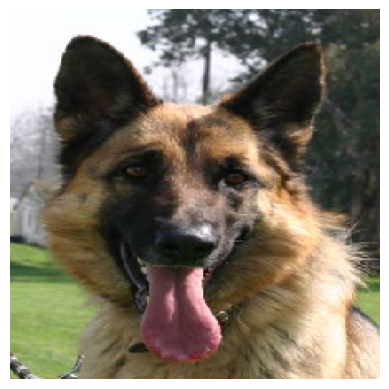

In [20]:
plt.imshow(img_arr)  # Display the image
plt.axis('off')  # Hide the axis
plt.show()  # Show the image

### Prediction

In [ ]:
# Expand the dimensions of the image array to match the input shape of the model
img_arr = np.expand_dims(img_arr, axis=0)  # Add a batch dimension to the image array
img_arr = preprocess_input(img_arr)  # Preprocess the image for the VGG16 model
result = model.predict(img_arr)  # Make predictions using the model

# print(result)  # Print the raw prediction result
# Decode the predictions to get the class labels and probabilities
decoded_result = decode_predictions(result, top=5)[0]  # Decode the predictions
# Print the top 5 predicted classes and their probabilities
for i, (imagenet_id, label, score) in enumerate(decoded_result):
    print(f"{i + 1}: {label} ({score:.2f})")  # Print the class label and probability
# Print the predicted class label
predicted_class = decoded_result[0][1]  # Get the predicted class label
print(f"Predicted class: {predicted_class}")  # Print the predicted class label
# Print the predicted class index
predicted_class_index = decoded_result[0][0]  # Get the predicted class index
print(f"Predicted class index: {predicted_class_index}")  # Print the predicted class index
# Print the predicted class probability
predicted_class_probability = decoded_result[0][2]  # Get the predicted class probability
print(f"Predicted class probability: {predicted_class_probability}")  # Print the predicted class probability
# Print the shape of the prediction result
print(f"Shape of prediction result: {result.shape}")  # Print the shape of the prediction result
# Print the shape of the image array
print(f"Shape of image array: {img_arr.shape}")  # Print the shape of the image array

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step
1: mosquito_net (0.11)
2: Samoyed (0.05)
3: Arctic_fox (0.03)
4: Maltese_dog (0.02)
5: toilet_tissue (0.02)
Predicted class: mosquito_net
Predicted class index: n03788365
Predicted class probability: 0.10531685501337051
Shape of prediction result: (1, 1000)
Shape of image array: (1, 224, 224, 3)
